In [4]:
from PythonMETAR import Metar
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io.img_tiles import GoogleTiles, OSM
import metpy.calc as mpcalc
from metpy.calc import reduce_point_density, wind_components
from metpy.calc import dewpoint_from_relative_humidity, wet_bulb_temperature
from metpy.calc import altimeter_to_station_pressure
from metpy.units import units
from metpy.io import parse_metar_to_dataframe
from metpy.io import metar
from metpy.plots import current_weather, sky_cover, StationPlot
import sage_data_client
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import pyart
import subprocess



In [36]:

bucket_date = datetime.datetime.utcnow().strftime('s3://noaa-nexrad-level2/2020/08/10/')
flist = subprocess.check_output(["aws","s3", "ls",  "--no-sign-request",  bucket_date + 'KDVN' +'/' ])
targs = []
for fl in flist.split():
    if 'KDVN' in str(fl):
        targs.append(fl.decode("utf-8"))

targs.sort()
fn = bucket_date + 'KDVN' +'/' + targs[182]
radar_KDVN = pyart.io.read_nexrad_archive(fn)


bucket_date = datetime.datetime.utcnow().strftime('s3://noaa-nexrad-level2/2020/08/10/')
flist = subprocess.check_output(["aws","s3", "ls",  "--no-sign-request",  bucket_date + 'KDMX' +'/' ])
targs = []
for fl in flist.split():
    if 'KDMX' in str(fl):
        targs.append(fl.decode("utf-8"))

targs.sort()
print(targs[182])
fn = bucket_date + 'KDMX' +'/' + targs[195]
radar_KDMX = pyart.io.read_nexrad_archive(fn)


bucket_date = datetime.datetime.utcnow().strftime('s3://noaa-nexrad-level2/2020/08/10/')
flist = subprocess.check_output(["aws","s3", "ls",  "--no-sign-request",  bucket_date + 'KILX' +'/' ])
targs = []
for fl in flist.split():
    if 'KILX' in str(fl):
        targs.append(fl.decode("utf-8"))

targs.sort()
print(targs[182])
fn = bucket_date + 'KILX' +'/' + targs[184]
radar_KILX = pyart.io.read_nexrad_archive(fn)



KDMX20200810_165837_V06
KILX20200810_175934_V06


In [34]:
print(targs[184])

KILX20200810_180507_V06


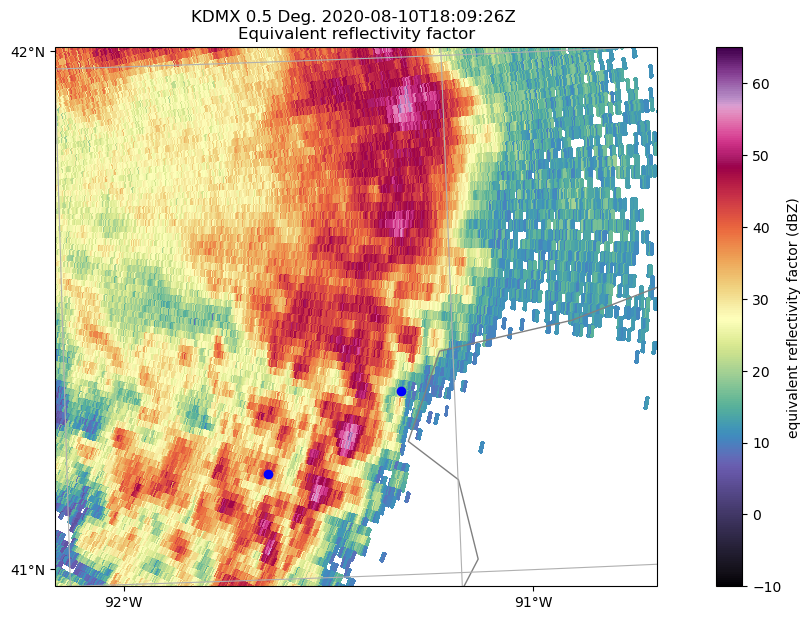

In [16]:
fig = plt.figure(figsize=(15, 7))
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=35,
                             standard_parallels=[35])

ax = fig.add_subplot(1, 1, 1, projection=proj)
myd = pyart.graph.RadarMapDisplay(radar_KDMX)

myd.plot_ppi_map('reflectivity', cmap = pyart.graph.cmweather.cm_colorblind.ChaseSpectral, ax=ax, projection=proj, vmin=-10, vmax=65)
#ax = plt.gca()
ax.set_extent((-92.0, -90.5, 41.0, 42.0))
locslon = [-91.4867832, -91.1377283]
locslat = [41.2042301, 41.3557788]
#ax.plot(locslon, locslat, marker='o', color='red',markersize=8, transform=proj)
#ax.plot(locslon[1], locslat[1], , color='yellow', markersize=8, transform=mercator)
myd.plot_line_geo(locslon, locslat, 'bo')

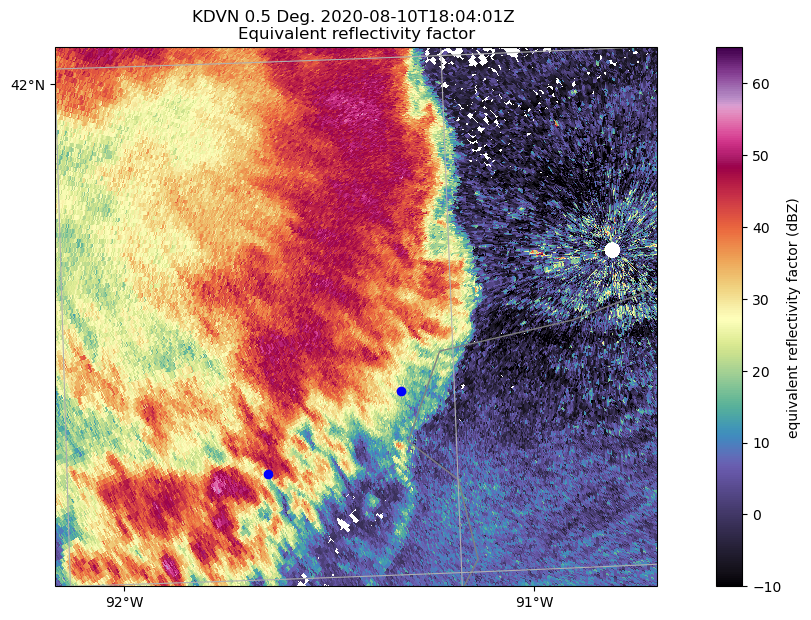

In [17]:
fig = plt.figure(figsize=(15, 7))
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=35,
                             standard_parallels=[35])

ax = fig.add_subplot(1, 1, 1, projection=proj)
myd = pyart.graph.RadarMapDisplay(radar_KDVN)

myd.plot_ppi_map('reflectivity', cmap = pyart.graph.cmweather.cm_colorblind.ChaseSpectral, ax=ax, projection=proj, vmin=-10, vmax=65)
#ax = plt.gca()
ax.set_extent((-92.0, -90.5, 41.0, 42.0))
locslon = [-91.4867832, -91.1377283]
locslat = [41.2042301, 41.3557788]
#ax.plot(locslon, locslat, marker='o', color='red',markersize=8, transform=proj)
#ax.plot(locslon[1], locslat[1], , color='yellow', markersize=8, transform=mercator)
myd.plot_line_geo(locslon, locslat, 'bo')

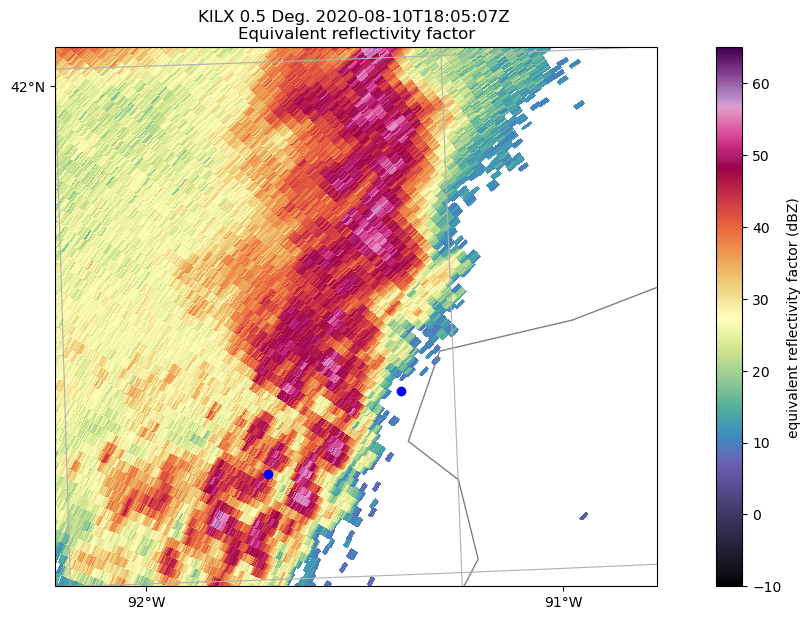

In [42]:
fig = plt.figure(figsize=(15, 7))
proj = ccrs.LambertConformal(central_longitude=-95, central_latitude=35,
                             standard_parallels=[35])

ax = fig.add_subplot(1, 1, 1, projection=proj)
myd = pyart.graph.RadarMapDisplay(radar_KILX)

myd.plot_ppi_map('reflectivity', cmap = pyart.graph.cmweather.cm_colorblind.ChaseSpectral, ax=ax, projection=proj, vmin=-10, vmax=65)
#ax = plt.gca()
ax.set_extent((-92.0, -90.5, 41.0, 42.0))
locslon = [-91.4867832, -91.1377283]
locslat = [41.2042301, 41.3557788]
#ax.plot(locslon, locslat, marker='o', color='red',markersize=8, transform=proj)
#ax.plot(locslon[1], locslat[1], , color='yellow', markersize=8, transform=mercator)
myd.plot_line_geo(locslon, locslat, 'bo')

In [18]:
pyart.map.grid_from_radars?

Signature:
pyart.map.grid_from_radars(
    radars,
    grid_shape,
    grid_limits,
    gridding_algo='map_gates_to_grid',
    copy_field_dtypes=True,
    **kwargs,
)
Docstring:
Map one or more radars to a Cartesian grid returning a Grid object.

Additional arguments are passed to :py:func:`map_to_grid` or
:py:func:`map_gates_to_grid`.

Parameters
----------
radars : Radar or tuple of Radar objects.
    Radar objects which will be mapped to the Cartesian grid.
grid_shape : 3-tuple of floats
    Number of points in the grid (z, y, x).
grid_limits : 3-tuple of 2-tuples
    Minimum and maximum grid location (inclusive) in meters for the
    z, y, x coordinates.
gridding_algo : 'map_to_grid' or 'map_gates_to_grid'
    Algorithm to use for gridding. 'map_to_grid' finds all gates within
    a radius of influence for each grid point, 'map_gates_to_grid' maps
    each radar gate onto the grid using a radius of influence and is
    typically significantly faster.
copy_field_dtypes : bool
    Wh

In [37]:
grid = pyart.map.grid_from_radars(
    [radar_KDVN, radar_KDMX, radar_KILX],
    grid_shape=(31, 201, 201),
    grid_limits=(
        (
            0.0,
            15000,
        ),
        (-100000.0, 100000.0),
        (-100000, 100000.0),
    ),
    grid_origin=[41.2042301, -91.4867832]
)

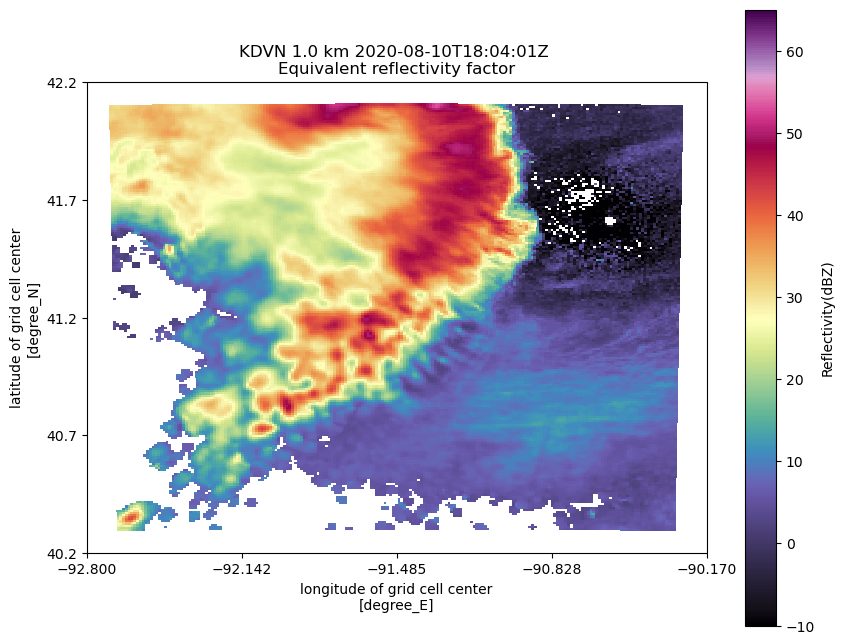

In [38]:
fig = plt.figure(figsize=[10, 8])
display = pyart.graph.GridMapDisplay(grid)
display.plot_grid("reflectivity", level=2,   cmap = pyart.graph.cmweather.cm_colorblind.ChaseSpectral, 
                  vmin=-10, vmax=65)

(-120.0, 120.0)

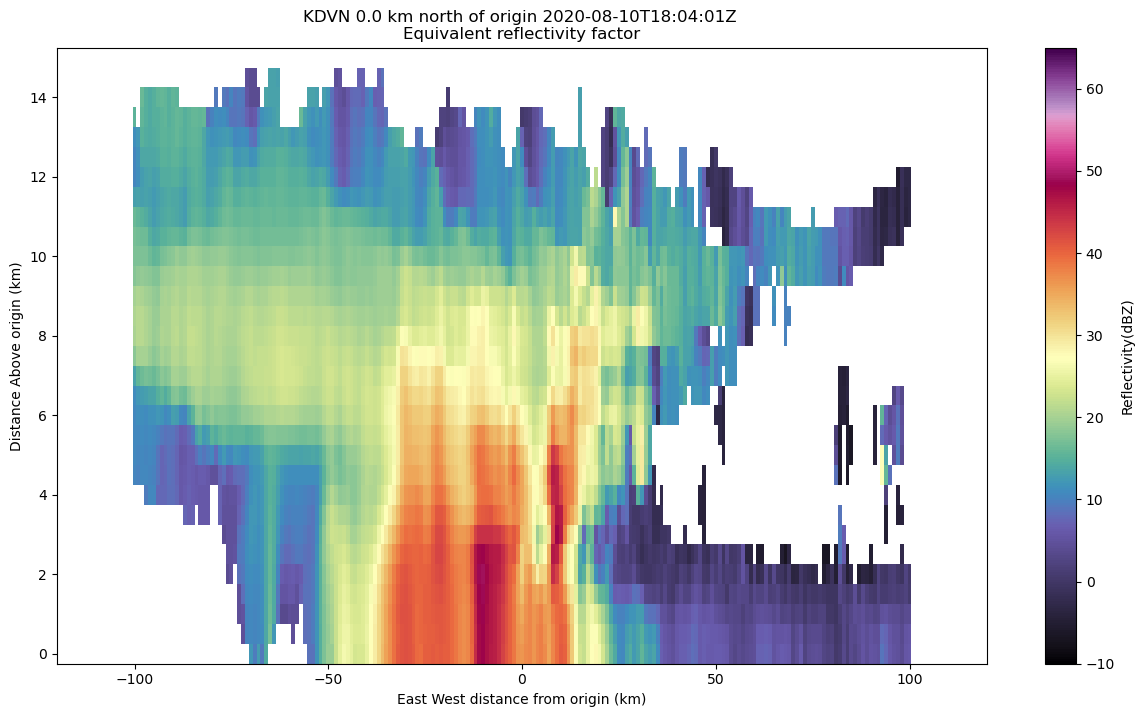

In [40]:
fig = plt.figure(figsize=[15, 8])
display.plot_latitude_slice("reflectivity", lat=41.2042301, cmap = pyart.graph.cmweather.cm_colorblind.ChaseSpectral, 
                  vmin=-10, vmax=65)
plt.xlim([-120, 120])